In [24]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว")
    except RuntimeError as e:
        print(e) 
        

GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว


In [36]:
import numpy as np
import cv2
from os import listdir
from os.path import isfile, join
from tqdm import tqdm
import tempfile
import tensorflow as tf
from keras.models import Sequential , load_model
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.applications import MobileNetV2
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available:  1
2.17.0


(<Axes: >, <matplotlib.image.AxesImage at 0x75308fc26180>)

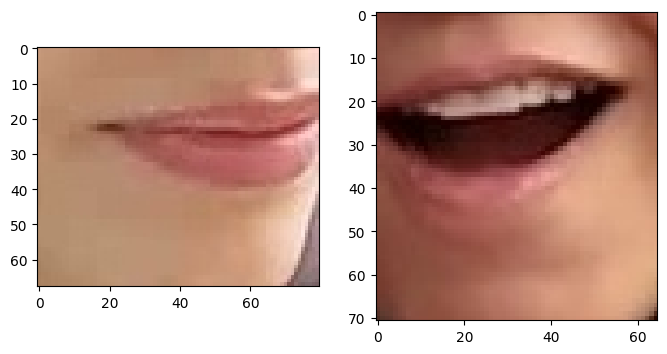

In [26]:
img1 = cv2.imread('assets/images/train/no-yawn/2760.jpg')
img1 = cv2.cvtColor(img1 , cv2.COLOR_BGR2RGB)

img2 = cv2.imread('assets/images/train/yawn/1.jpg')
img2 = cv2.cvtColor(img2 , cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)

In [27]:
width = 128
num_classes = 2
trainpath = 'assets/images/train/'
testpath = 'assets/images/test/'
trainImg = [trainpath+f for f in listdir(trainpath)]
testImg = [testpath+f for f in listdir(testpath)]
img_size = 128
batch_size = 16

In [28]:
# class GrayImageDataGenerator(Sequence):
#     def __init__(self, generator):
#         self.generator = generator

#     def __len__(self):
#         return len(self.generator)

#     def __getitem__(self, i):
#         x_batch, y_batch = self.generator[i]
#         x_batch_gray = np.expand_dims(np.mean(x_batch, axis=-1), axis=-1)
#         return x_batch_gray, y_batch
    

#     def plotImageFromDataset(self):
#         # ดึง batch แรกจาก self
#         x_batch, y_batch = next(iter(self))

#         # ดูข้อมูล
#         print("Batch shape:", x_batch.shape)
#         print("Labels:", y_batch[:10])

#         # แสดงภาพ 9 รูปแรก
#         plt.figure(figsize=(8, 8))
#         for i in range(9):
#             plt.subplot(3, 3, i + 1)
#             img = x_batch[i].squeeze()  # เอา channel ออก (เพราะ grayscale)
#             plt.imshow(img, cmap='gray')
#             plt.title(f"Label: {int(y_batch[i])}")
#             plt.axis('off')
#         plt.tight_layout()
#         plt.show()\
    
def color2gray(data):
    for x_batch, y_batch in data:
        # 1. หาค่าเฉลี่ยของทุก Channel สี (รวม RGB เข้าด้วยกัน)
        x_batch_mean = np.mean(x_batch, axis=-1)
        
        # 2. เพิ่มมิติ Channel กลับเข้าไป
        x_batch_gray = np.expand_dims(x_batch_mean, axis=-1)
        
        # ส่ง Batch ขาวดำออกไป
        yield x_batch_gray, y_batch
    
def plotImageFromDataset(image):
    print(image)
    # ดึง batch แรกจาก image
    x_batch, y_batch = next(iter(image))

        # ดูข้อมูล
    print("Batch shape:", x_batch.shape)
    print("Labels:", y_batch)

        # แสดงภาพ 9 รูปแรก
    plt.figure(figsize=(8, 8))
    for i in range(1):
        plt.subplot(3, 3, i + 1)
        img = x_batch[i].squeeze()  # เอา channel ออก (เพราะ grayscale)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {int(y_batch[i])}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    

def img2data(path):
    rawImgs = []
    labels = []
    i=0
    for imagePath in (path):
        for item in tqdm(listdir(imagePath)):
            
            if i == 8000 and  (np.where(imagePath == trainpath) or np.where(imagePath == testpath)):
                return rawImgs, labels
                        
            file = join(imagePath, item)
            if file[-1] =='g':
                img = cv2.imread(file , cv2.COLOR_BGR2RGB)
                img = cv2.resize(img ,(width,width))
                rawImgs.append(img)
                
                l = imagePath.split('/')[-1]
                if l == 'no-yawn':
                    labels.append([1,0])         
                elif l == 'yawn':
                    labels.append([0,1])
                i+=1    
            
    return rawImgs, labels


def rgb2gray(images):
    grayImgs = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        grayImgs.append(gray)
    print(grayImgs[0].shape)
    
    return grayImgs

In [29]:
x_train, y_train = img2data(trainImg)
x_test, y_test = img2data(testImg)

x_train = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_RGB2GRAY), (img_size, img_size)) for image in x_train])
y_train = np.array(y_train)
x_test = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_RGB2GRAY), (img_size, img_size)) for image in x_test])
y_test = np.array(y_test)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

  0%|          | 0/2591 [00:00<?, ?it/s]

100%|██████████| 758/758 [00:00<00:00, 2179.90it/s]


((5119, 128, 128), (5119, 2), (1080, 128, 128), (1080, 2))

In [30]:
imagePath = 'assets/images/train/'
testPath = 'assets/images/test/'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_gen = train_datagen.flow_from_directory(
    imagePath,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)

val_gen = train_datagen.flow_from_directory(
    testPath,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)

train_gen_gray = color2gray(train_gen)
print(train_gen_gray)
val_gen_gray = color2gray(val_gen)

# plotImageFromDataset(train_gen_gray)

# train_ds = tf.keras.utils.image_dataset_from_directory(
#     imagePath,
#     labels='inferred',
#     label_mode='categorical',
#     image_size=(img_size, img_size),
#     batch_size=batch_size,
#     validation_split=0.2,
#     subset='training',
#     seed=123
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     testPath,
#     labels='inferred',
#     label_mode='categorical',
#     image_size=(img_size, img_size),
#     batch_size=batch_size,
#     validation_split=0.2,
#     subset='validation',
#     seed=123
# )

# plotImageFromDataset(train_ds,train_ds.class_names)

# train_generator_gray = GrayImageDataGenerator(train_generator)

# train_generator_gray.plotImageFormDatagen()

Found 5119 images belonging to 2 classes.
Found 1080 images belonging to 2 classes.
<generator object color2gray at 0x75308db29a80>


In [31]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(img_size,img_size,1)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 256)  │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,978 (2.18 MB)

 Trainable params: 570,978 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# history = model.fit(
#     train_gen_gray,                # Pass training labels as 'y'
#     batch_size=8,
#     steps_per_epoch=8208,
#     epochs=50,
#     validation_data=(val_gen_gray), # validation_data remains a tuple (X_val, Y_val)
#     callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
# )

history = model.fit(
    x = x_train,
    y = y_train, # Pass training labels as 'y'
    batch_size=8,
    steps_per_epoch=8208,
    epochs=50,
    validation_data=(x_test, y_test), # validation_data remains a tuple (X_val, Y_val)
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
)

Epoch 1/50


I0000 00:00:1763278251.944897   63464 service.cc:146] XLA service 0x7530900145d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763278251.945295   63464 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2025-11-16 07:30:52.020951: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-16 07:30:52.545461: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
2025-11-16 07:30:54.341992: W external/local_tsl/tsl/framework/bfc_allocator.cc:363] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance over

  13/8208 ━━━━━━━━━━━━━━━━━━━━ 1:51 14ms/step - accuracy: 0.5209 - loss: 5.4240

2025-11-16 07:30:56.039855: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 72 bytes spill stores, 72 bytes spill loads

I0000 00:00:1763278256.052538   63464 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 638/8208 ━━━━━━━━━━━━━━━━━━━━ 1:12 10ms/step - accuracy: 0.7990 - loss: 0.8871

...

8208/8208 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9668 - loss: 0.0981 - val_accuracy: 0.9843 - val_loss: 0.0682
Epoch 27/50
 638/8208 ━━━━━━━━━━━━━━━━━━━━ 1:37 13ms/step - accuracy: 0.9669 - loss: 0.0969

2025-11-16 07:34:38.068124: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12256427218970066373
2025-11-16 07:34:38.068211: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1519489463665833528


8208/8208 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9675 - loss: 0.1034 - val_accuracy: 0.9731 - val_loss: 0.0939
Epoch 28/50
8208/8208 ━━━━━━━━━━━━━━━━━━━━ 7s 798us/step - accuracy: 0.9682 - loss: 0.0972 - val_accuracy: 0.9769 - val_loss: 0.0764
Epoch 29/50
 638/8208 ━━━━━━━━━━━━━━━━━━━━ 1:38 13ms/step - accuracy: 0.9722 - loss: 0.0780

2025-11-16 07:34:53.540215: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12256427218970066373
2025-11-16 07:34:53.540287: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1519489463665833528


8208/8208 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9678 - loss: 0.0953 - val_accuracy: 0.9722 - val_loss: 0.0797
Epoch 30/50
8208/8208 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9687 - loss: 0.0945 - val_accuracy: 0.9852 - val_loss: 0.0491


In [37]:
# model.save('yawn_model.keras')

_, keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(model, keras_file, include_optimizer=False)
print('Saved baseline model to:', keras_file)

plt.figure(figsize=(10,4))
plt.subplot(121),
plt.title('model accuracy');plt.ylabel('accuracy');plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy'])

plt.subplot(122)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['loss']);plt.plot(history.history['val_loss'])

/tmp/ipykernel_1159/3625803701.py:4: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  tf.keras.models.save_model(model, keras_file, include_optimizer=False)


AttributeError: 'Sequential' object has no attribute '_is_graph_network'

In [39]:
# If you have a saved model on disk you can use:
# converter = tf.lite.TFLiteConverter.from_saved_model("model_saved")

# Convert directly from the in-memory Keras model:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
open("model_int8.tflite", "wb").write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpd1l0o3rx/assets


INFO:tensorflow:Assets written to: /tmp/tmpd1l0o3rx/assets


Saved artifact at '/tmp/tmpd1l0o3rx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor_2160')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  128851431342928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431343504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431343120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431344464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431344080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431345616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431342736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431346384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431345424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431347344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128851431

W0000 00:00:1763278909.763359    1159 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1763278909.763420    1159 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2025-11-16 07:41:49.763916: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd1l0o3rx
2025-11-16 07:41:49.764548: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-16 07:41:49.764583: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpd1l0o3rx
2025-11-16 07:41:49.770649: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2025-11-16 07:41:49.772300: I tensorflow/cc/saved_model/loader.cc:238] Restoring SavedModel bundle.
2025-11-16 07:41:49.818882: I tensorflow/cc/saved_model/loader.cc:222] Running initialization op on SavedModel bundle at path: /tmp/tmpd1l0o3rx
2025-11-16 07:41:49.829583: I tensorflow/cc/saved_model/loader.cc

590808